In [7]:
import math
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [8]:
nurseData = pd.read_csv('../dataMyself/护工信息_已脱敏.csv')
nurseData

,护工ID,护工姓名,性别,年龄,省,民族,宗教信仰,学历,普通话程度,方言程度,...,在岗时间,擅长科室,擅长科室种类,接单数,活跃度,评分（满分5分）,所属服务商,常驻医院,主要负责病区,其他负责病区
0,478,史小平,女,53,河南,汉族,无宗教信仰,初中,能听懂,能听懂能交流,...,505,无,0,23,0.16,1,NBAX,WT,绣山医学楼,无
1,1494,张清荣,女,51,贵州,汉族,无宗教信仰,初中,能听懂,能听懂能交流,...,395,无,0,8,0.06,4,JSMSJ,FQ,7号楼,6号楼
2,1495,余世梅,女,54,河南,汉族,无宗教信仰,文盲,能听懂能交流,不熟练,...,395,心内科,1,5,0.07,0,JSMSJ,FQ,3号楼,7号楼
3,1496,王正凡,男,59,重庆,汉族,无宗教信仰,初中,能听懂,能听懂能交流,...,395,无,0,2,0.01,5,JSMSJ,FQ,7号楼,无
4,1497,周新云,女,57,河南,汉族,无宗教信仰,初中,能听懂,能听懂能交流,...,395,无,0,6,0.05,4,JSMSJ,FQ,7号楼,6号楼
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
569,6274,任雪梅,女,37,河南,汉族,无宗教信仰,初中,能听懂能交流,不熟练,...,10,无,0,1,0.20,0,NBAX,WT,1号楼,无
570,6277,董玲,女,51,江苏,汉族,无宗教信仰,文盲,能听懂,能听懂,...,10,无,0,1,0.40,0,JSMSJ,FQ,7号楼,无
571,6308,潘敏发,男,54,江苏,汉族,无宗教信仰,小学,能听懂能交流,能听懂,...,7,无,0,1,0.71,3,SHZF,FQ,6号楼,无
572,6312,丁碧芳,女,61,重庆,汉族,无宗教信仰,文盲,能听懂,不熟练,...,5,无,0,1,1.00,0,JSMSJ,YH,3号楼,无


In [ ]:
# 统计离散型特征分布
def count(df, col):
    res = []
    values = df[col].unique().tolist()
    for _, val in enumerate(values):
        res.append(df[df[col] == val].shape[0])

    return values, res

In [ ]:
count(nurseData, '常驻医院')

In [ ]:
nurseData.columns

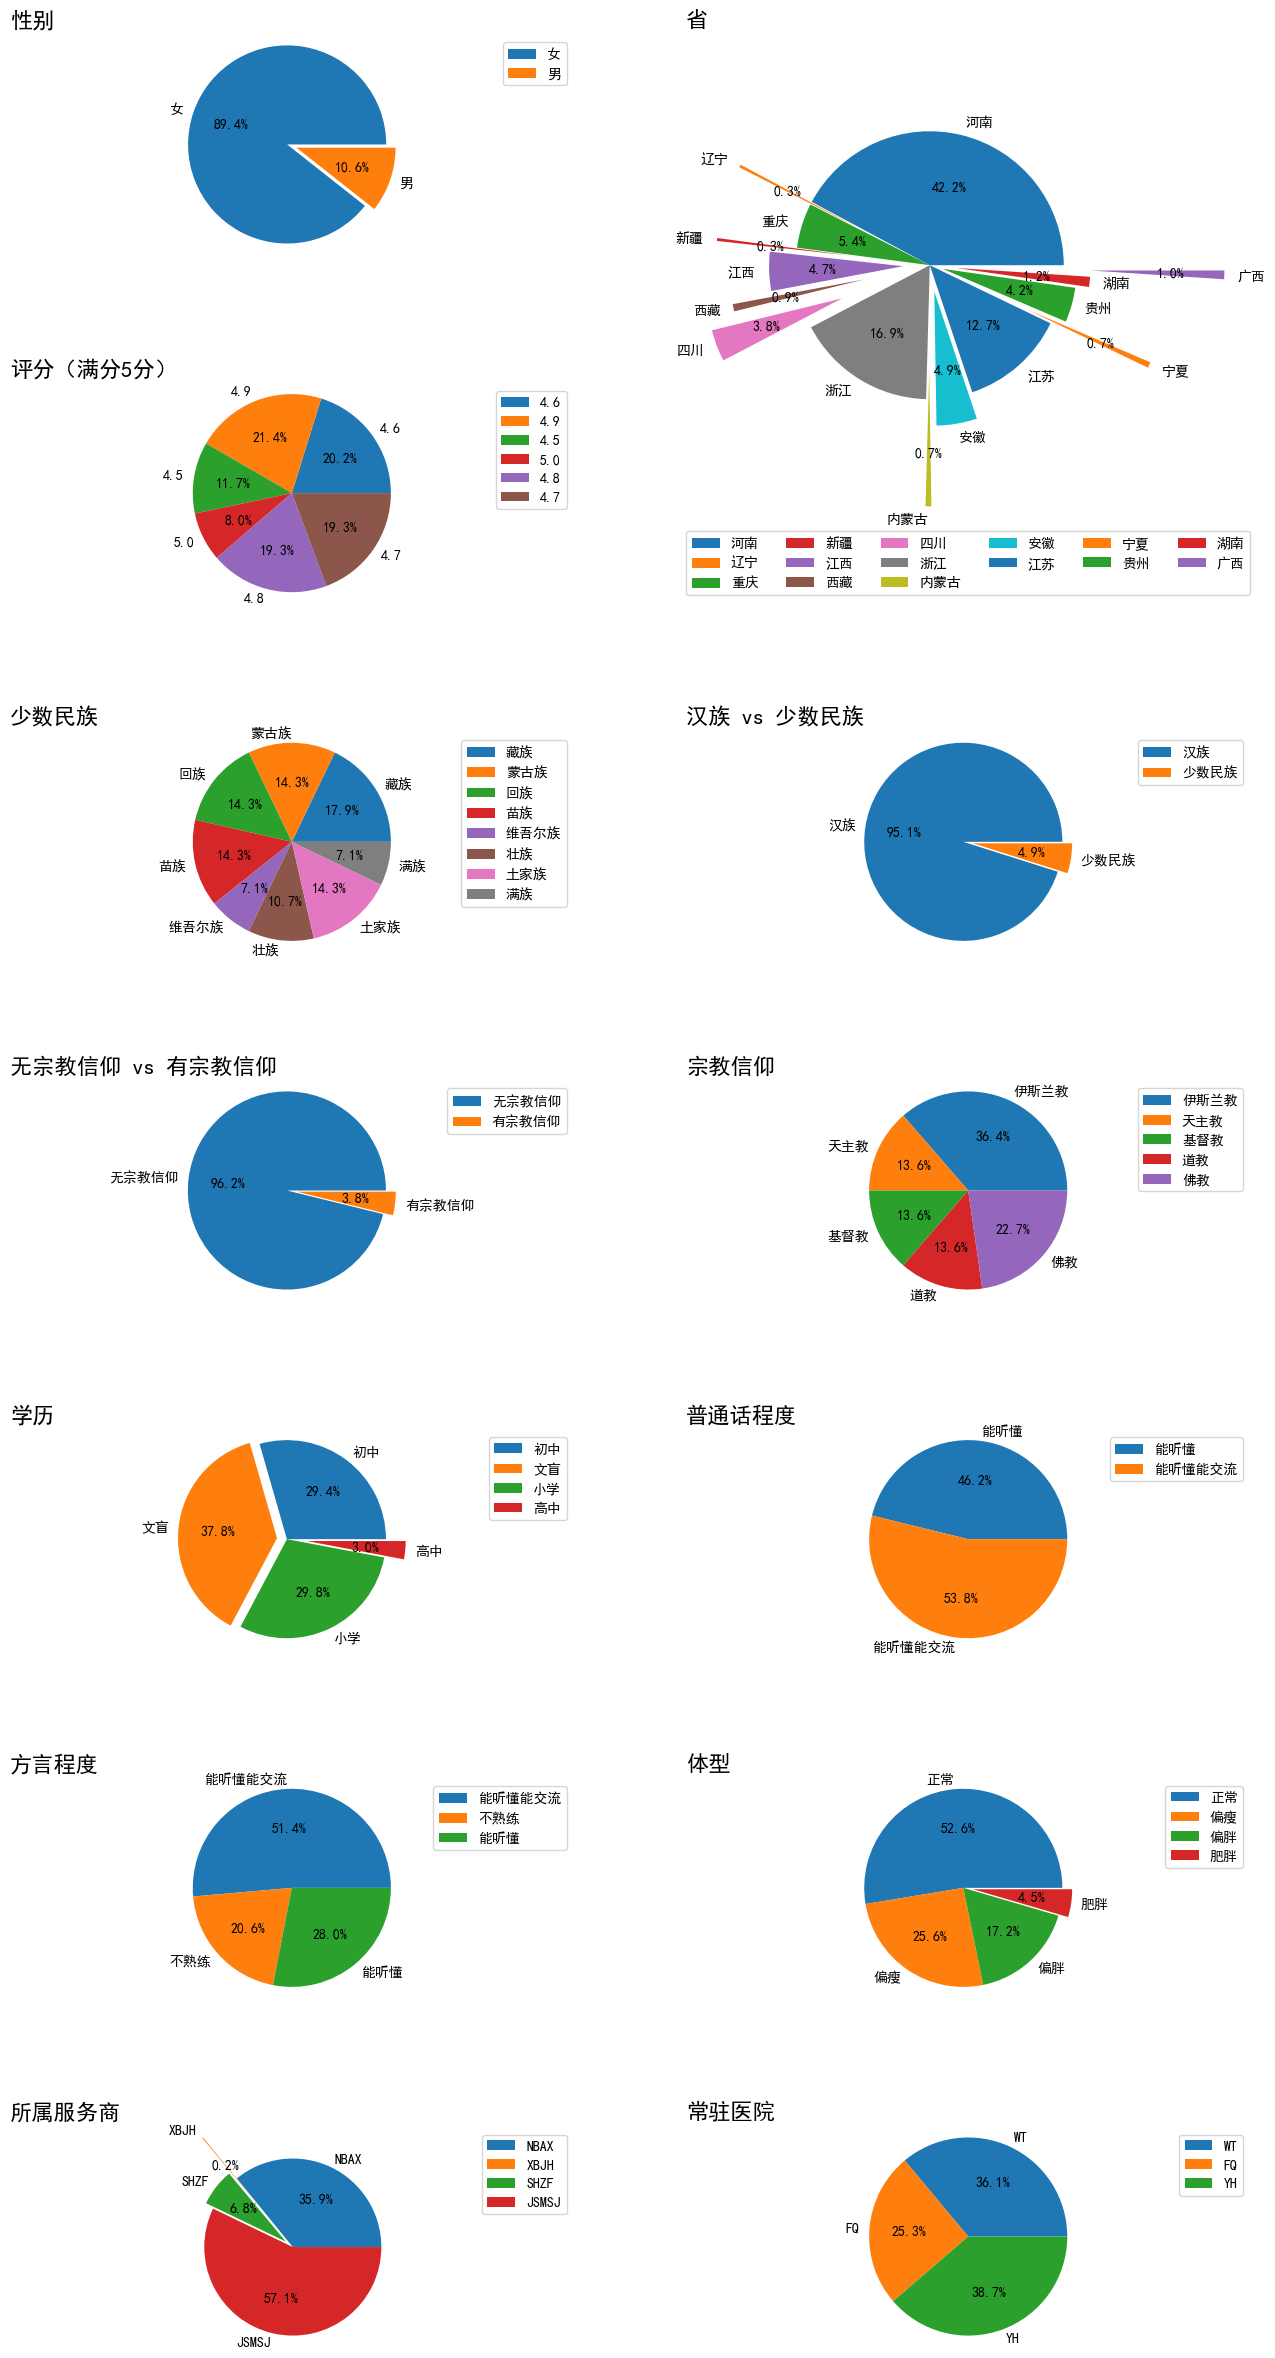

In [5]:
fig = plt.figure(figsize=(16, 30), dpi=100)
fig.subplots_adjust(hspace=0.6)
gs = plt.GridSpec(7, 2)

titles = ['性别', '省', '评分（满分5分）', '少数民族', '汉族 vs 少数民族', '无宗教信仰 vs 有宗教信仰', '宗教信仰', '学历', '普通话程度', '方言程度', '体型', '所属服务商', '常驻医院']
sizes = [[513, 61],
         [242, 2, 31, 2, 27, 5, 22, 97, 4, 28, 73, 4, 24, 7, 6],
         [116, 123, 67, 46, 111, 111],
         [5, 4, 4, 4, 2, 3, 4, 2],
         [546, 28],
         [552, 22],
         [8, 3, 3, 3, 5],
         [169, 217, 171, 17],
         [265, 309],
         [295, 118, 161],
         [302, 147, 99, 26],
         [206, 1, 39, 328],
         [207, 145, 222]
        ]
labels = [['女', '男'],
          ['河南', '辽宁', '重庆', '新疆', '江西', '西藏', '四川', '浙江', '内蒙古', '安徽', '江苏', '宁夏', '贵州', '湖南', '广西'],
          [4.6, 4.9, 4.5, 5.0, 4.8, 4.7],
          ['藏族', '蒙古族', '回族', '苗族', '维吾尔族', '壮族', '土家族', '满族'],
          ['汉族', '少数民族'],
          ['无宗教信仰', '有宗教信仰'],
          ['伊斯兰教', '天主教', '基督教', '道教', '佛教'],
          ['初中', '文盲', '小学', '高中'],
          ['能听懂', '能听懂能交流'],
          ['能听懂能交流', '不熟练', '能听懂'],
          ['正常', '偏瘦', '偏胖', '肥胖'],
          ['NBAX', 'XBJH', 'SHZF', 'JSMSJ'],
          ['WT', 'FQ', 'YH']
         ]
configs = [[0, 0.1],
           [0, 0.6, 0, 0.6, 0.2, 0.5, 0.7, 0, 0.8, 0.2, 0, 0.8, 0.1, 0.2, 1.2],
           [0] * 6,
           [0] * 8,
           [0, 0.1],
           [0, 0.1],
           [0] * 5,
           [0, 0.1, 0, 0.2],
           [0, 0],
           [0, 0, 0],
           [0, 0, 0, 0.1],
           [0, 0.6, 0.1, 0],
           [0] * 3
          ]
for idx in range(len(titles)):
    if idx == 0:
        axs = fig.add_subplot(gs[0, 0])
    elif idx == 1:
        axs = fig.add_subplot(gs[0:2, 1])
    elif idx == 2:
        axs = fig.add_subplot(gs[1, 0])
    else:
        if idx % 2 == 0:
            axs = fig.add_subplot(gs[idx // 2, 1])
        else:
            axs = fig.add_subplot(gs[idx // 2 + 1, 0])

    axs.pie(sizes[idx], labels=labels[idx], autopct='%1.1f%%', explode=configs[idx])
    axs.set_title(titles[idx], loc='left', fontdict={
        'fontsize': 16,
        'fontweight': 'bold',
    })
    axs.axis('equal')
    if idx == 1:
        axs.legend(loc='lower center', ncol=6)
    else:
        axs.legend(loc='best')

# plt.savefig('护工离散型特征统计_plt_1.png')
plt.show()

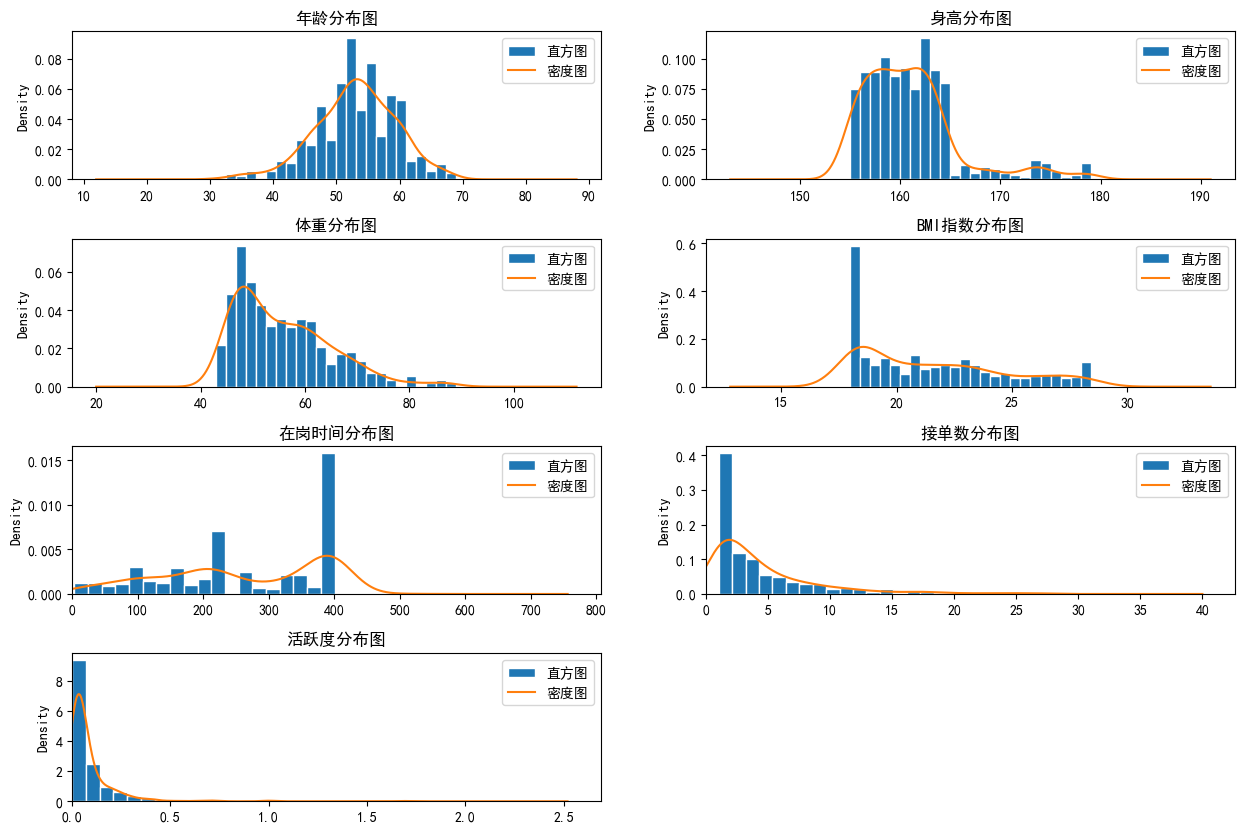

In [10]:
numberCols = ['年龄', '身高', '体重', 'BMI指数', '在岗时间', '接单数', '活跃度']

fig = plt.figure(figsize=(15, 10), dpi=100)
fig.subplots_adjust(hspace=0.4)

for idx, col in enumerate(numberCols):
    plt.subplot(4, 2, idx + 1)
    plt.hist(nurseData[col], density=True, edgecolor='w', label='直方图', bins=round(math.sqrt(nurseData.shape[0])))
    nurseData[col].plot(kind='kde', label='密度图')
    xlim = plt.xlim()
    if xlim[0] < 0:
        plt.xlim([0, xlim[1]])

    plt.title(col + '分布图')
    plt.legend()

plt.savefig('护工连续型特征统计_1.png')
plt.show()